In [1]:
import sqlite3
import pandas as pd

In [ ]:
def gather_data(
    data_path,
    standard_type,
    maxMatch=True,
    minAssaySize=20,
    maxAssaySize=100,
    onlyDocs=True,
    removeMutants=True,
    onlyHighConfidence=True,
):
    connection = sqlite3.connect(data_path)
    cursor = connection.cursor()

    # Drop temporary tables if they already exist
    cursor.execute("DROP TABLE IF EXISTS temp_assays")

    if standard_type in ("Ki", "IC50"):
        cursor.execute(
            """
        CREATE TEMPORARY TABLE temp_assays AS
        SELECT 
            assay_id, assays.chembl_id AS assay_chembl_id, description, tid,
            targets.chembl_id AS target_chembl_id, COUNT(DISTINCT molregno) AS cnt,
            pref_name, assays.doc_id AS doc_id, docs.year AS doc_date, variant_id
        FROM activities
        JOIN assays USING(assay_id)
        JOIN docs ON assays.doc_id = docs.doc_id
        JOIN target_dictionary AS targets USING(tid)
        WHERE 
            pchembl_value IS NOT NULL
            AND standard_type = ?
            AND standard_units = 'nM'
            AND data_validity_comment IS NULL
            AND standard_relation = '='
            AND target_type = 'SINGLE PROTEIN'
        GROUP BY assay_id, assays.chembl_id, description, tid, targets.chembl_id, 
                 pref_name, assays.doc_id, docs.year, variant_id
        ORDER BY cnt DESC;
        """,
            (standard_type,),
        )
    else:
        raise NotImplementedError("Only Ki and IC50 are currently supported")

    # Additional curation steps
    if onlyDocs:
        cursor.execute("DELETE FROM temp_assays WHERE doc_date IS NULL")
    if removeMutants:
        cursor.execute("""
        DELETE FROM temp_assays
        WHERE variant_id IS NOT NULL 
          OR LOWER(description) LIKE '%mutant%'
          OR LOWER(description) LIKE '%mutation%'
          OR LOWER(description) LIKE '%variant%';
        """)
    if onlyHighConfidence:
        cursor.execute("ALTER TABLE temp_assays RENAME TO temp_assays_1")
        cursor.execute("""
        CREATE TEMPORARY TABLE temp_assays AS
        SELECT ta1.* 
        FROM temp_assays_1 ta1
        JOIN assays USING(assay_id)
        WHERE confidence_score = 9;
        """)
        cursor.execute("DROP TABLE temp_assays_1")

    # Goldilocks table creation
    cursor.execute("DROP TABLE IF EXISTS goldilocks")
    cursor.execute(
        """
    CREATE TEMPORARY TABLE goldilocks AS
    SELECT 
        assay_id, tid, molregno, pchembl_value, temp_assays.doc_id, standard_type, activity_id
    FROM activities
    JOIN temp_assays USING(assay_id)
    WHERE 
        pchembl_value IS NOT NULL
        AND standard_units = 'nM'
        AND data_validity_comment IS NULL
        AND standard_relation = '='
        AND cnt >= ? AND cnt <= ?;
    """,
        (minAssaySize, maxAssaySize),
    )

    if standard_type in ("Ki", "IC50"):
        cursor.execute(
            "DELETE FROM goldilocks WHERE standard_type != ?", (standard_type,)
        )
    try:
        # This removes a few more activities from goldilocks
        activity_data = pd.read_sql(
            """
        SELECT goldilocks.activity_id,
               goldilocks.assay_id,
               goldilocks.doc_id,
               goldilocks.molregno,
               tid,
               compound_structures.canonical_smiles, 
               component_sequences.component_id AS component_id,
               component_sequences.sequence AS component_sequence,
               goldilocks.pchembl_value
        FROM goldilocks
        JOIN compound_structures USING (molregno)
        JOIN target_components USING (tid)
        JOIN component_sequences ON target_components.component_id = component_sequences.component_id
        WHERE component_sequences.sequence IN (
            SELECT sequence
            FROM component_sequences
            GROUP BY sequence
            HAVING COUNT(*) = 1
        );
        """,
            connection,
        )
        return activity_data
    finally:
        connection.close()


activities = gather_data(
    "../data/chembl_32/chembl_32_sqlite/chembl_32.db",
    "IC50",
    maxMatch=False,
    minAssaySize=20,
    maxAssaySize=100,
    onlyDocs=True,
    removeMutants=True,
    onlyHighConfidence=True,
)

In [4]:
activities

,activity_id,assay_id,doc_id,molregno,tid,canonical_smiles,component_id,component_sequence,pchembl_value
0,13877505,1284012,76540,1612260,10477,CCC(CC)C(=O)Nc1ccc(N2CCN(C(c3cccc(F)c3)c3ncco3...,2337,MGPIGAEADENQTVEEMKVEQYGPQTTPRGELVPDPEPELIDSTKL...,8.15
1,13877506,1284012,76540,1612259,10477,CCN(CC)C(=O)C(c1ccccc1)N1CCN(c2ccc(-c3nc(C(C)C...,2337,MGPIGAEADENQTVEEMKVEQYGPQTTPRGELVPDPEPELIDSTKL...,7.96
2,13877507,1284012,76540,1612258,10477,CCC(CC)C(=O)Nc1ccc(N2CCN(C(c3ccccc3)c3ncccn3)C...,2337,MGPIGAEADENQTVEEMKVEQYGPQTTPRGELVPDPEPELIDSTKL...,7.48
3,13877508,1284012,76540,1612257,10477,CCC(CC)C(=O)Nc1ccc(N2CCN(C(c3ccccc3)C3CCOC3)CC...,2337,MGPIGAEADENQTVEEMKVEQYGPQTTPRGELVPDPEPELIDSTKL...,7.47
4,13877509,1284012,76540,1612256,10477,CCC(CC)C(=O)Nc1ccc(N2CCN(C(c3ccccc3)c3cc(C)no3...,2337,MGPIGAEADENQTVEEMKVEQYGPQTTPRGELVPDPEPELIDSTKL...,7.42
...,...,...,...,...,...,...,...,...,...
259818,24505004,2169001,122230,2738616,87,Cc1c(C(=O)Nc2cccc(/N=N/c3ccccc3)c2)nn(CCCCCO)c...,172,MKSILDGLADTTFRTITTDLLYVGSNDIQYEDIKGDMASKLGYFPQ...,5.21
259819,24505005,2169001,122230,2727064,87,Cc1c(C(=O)NCCCc2ccccc2/N=N/c2ccccc2)nn(CCCCCO)...,172,MKSILDGLADTTFRTITTDLLYVGSNDIQYEDIKGDMASKLGYFPQ...,5.05
259820,24505006,2169001,122230,2731852,87,Cc1c(C(=O)NCCc2ccc(/N=N/c3ccccc3)cc2)nn(CCCCCO...,172,MKSILDGLADTTFRTITTDLLYVGSNDIQYEDIKGDMASKLGYFPQ...,5.10
259821,24505007,2169001,122230,2724714,87,Cc1c(C(=O)NCCc2cccc(/N=N/c3ccccc3)c2)nn(CCCCCO...,172,MKSILDGLADTTFRTITTDLLYVGSNDIQYEDIKGDMASKLGYFPQ...,5.23


In [5]:
import matplotlib.pyplot as plt

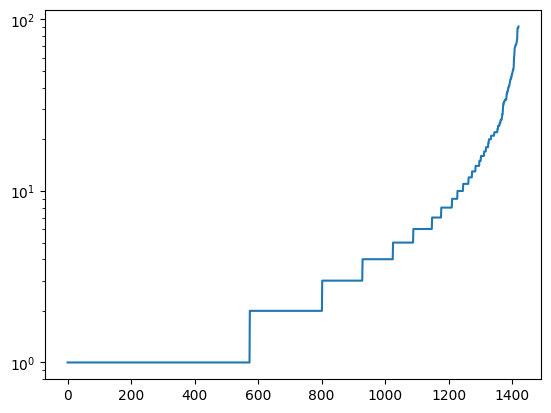

In [6]:
plt.plot(
    activities.groupby("tid")
    .nunique()
    .sort_values("assay_id")[["assay_id"]]
    .values.flatten()
)
plt.yscale("log")

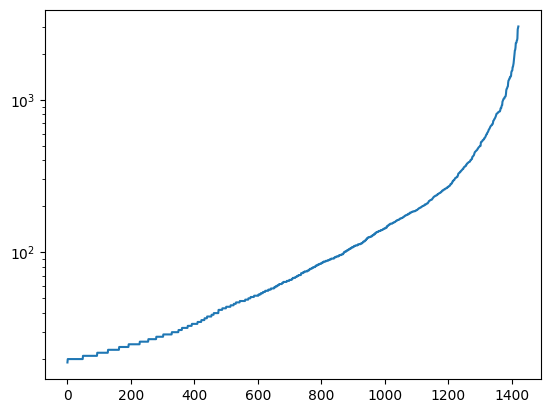

In [7]:
plt.plot(
    activities.groupby("tid")
    .nunique()
    .sort_values("activity_id")[["activity_id"]]
    .values.flatten()
)
plt.yscale("log")

In [8]:
activities.to_csv("../data/landrum.csv")

In [9]:
activities = gather_data(
    "../data/chembl_32/chembl_32_sqlite/chembl_32.db",
    "IC50",
    maxMatch=False,
    minAssaySize=5,
    maxAssaySize=1e6,
    onlyDocs=True,
    removeMutants=True,
    onlyHighConfidence=True,
)

In [10]:
activities.to_csv("../data/landrum_large.csv")

In [12]:
activities = gather_data(
    "../data/chembl_32/chembl_32_sqlite/chembl_32.db",
    "IC50",
    maxMatch=False,
    minAssaySize=2,
    maxAssaySize=5e6,
    onlyDocs=False,
    removeMutants=True,
    onlyHighConfidence=False,
)

In [13]:
activities.to_csv("../data/omnivore.csv")

In [3]:
def run_query(query, data_path="../data/chembl_32/chembl_32_sqlite/chembl_32.db"):
    connection = sqlite3.connect(data_path)
    try:
        return pd.read_sql(query, connection)
    finally:
        connection.close()

In [4]:
sol_df = run_query("""
        SELECT *
        FROM activities
        WHERE standard_type = 'Solubility'
        """)

In [5]:
sol_df

,activity_id,assay_id,doc_id,record_id,molregno,standard_relation,standard_value,standard_units,standard_flag,standard_type,...,toid,upper_value,standard_upper_value,src_id,type,relation,value,units,text_value,standard_text_value
0,32006,18266,8329,347523,292816,=,248400.0,ug.mL-1,1,Solubility,...,None,NaN,None,1,Solubility,=,24.84,g dl-1,None,None
1,32007,18264,8329,347523,292816,=,170000.0,ug.mL-1,1,Solubility,...,None,NaN,None,1,Solubility,=,17.00,g dl-1,None,None
2,32012,18266,8329,347504,293747,=,238800.0,ug.mL-1,1,Solubility,...,None,NaN,None,1,Solubility,=,23.88,g dl-1,None,None
3,32013,18264,8329,347504,293747,=,172900.0,ug.mL-1,1,Solubility,...,None,NaN,None,1,Solubility,=,17.29,g dl-1,None,None
4,32214,18883,5696,168846,551840,=,21000.0,ug.mL-1,1,Solubility,...,None,NaN,None,1,S,=,21.00,mg ml-1,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50998,24518297,2172830,122354,3839233,2725677,=,15000.0,nM,1,Solubility,...,None,NaN,None,1,solubility,=,15.00,uM,None,None
50999,24518298,2172830,122354,3839234,2726395,=,29000.0,nM,1,Solubility,...,None,NaN,None,1,solubility,=,29.00,uM,None,None
51000,24518299,2172831,122354,3839218,2723475,=,37000.0,nM,1,Solubility,...,None,NaN,None,1,solubility,=,37.00,uM,None,None
51001,24518300,2172831,122354,3839222,2724614,=,35000.0,nM,1,Solubility,...,None,NaN,None,1,solubility,=,35.00,uM,None,None


In [6]:
sol_df[["units"]].value_counts()

units      
uM             24436
ug ml-1        15294
mg/ml           4987
mg ml-1         1918
mM              1561
mg/L             786
ug/ml            405
g/L              214
g dl-1           124
umol/L           123
nM               106
ng/ml            104
ug mL-1           56
M                 53
ug/mL             49
g/ml              43
mg l-1            37
mmol/L            36
M l-1             28
mg mL-1           26
microg/ml         26
10'-3mg/ml        23
%                 22
mol/L             22
g                 21
10'-4 mol/L       20
g l-1             20
uM/L              17
10'-3 mol/L       17
uM/ml             12
ug/uL             12
ug/L              12
10'-7mol/L         9
10^3g/L            9
microM             8
ng ml-1            8
mg L-1             8
mg/dl              7
10'-3M             7
mm                 7
10'-6mg/ml         5
10'-2 mol/L        5
umol/ml            5
mg/mL              5
10'-5 mol/L        4
g ml-1             4
mg kg-1            4
1

In [10]:
atyps = run_query("""
    select standard_type, count(standard_type) as cnt
    from activities
    group by standard_type
    order by cnt desc
    """)
atyps.head(20)

,standard_type,cnt
0,Potency,4473542
1,GI50,2614820
2,IC50,2582500
3,Inhibition,1434673
4,Percent Effect,1328366
5,Activity,1158674
6,Ki,751178
7,MIC,683458
8,EC50,486455
9,INHIBITION,339133


In [12]:
run_query("""
    select *
    from activities
    where standard_type = 'Percent Effect'
    """)

,activity_id,assay_id,doc_id,record_id,molregno,standard_relation,standard_value,standard_units,standard_flag,standard_type,...,toid,upper_value,standard_upper_value,src_id,type,relation,value,units,text_value,standard_text_value
0,20783337,1998102,103486,2913407,1904010,=,7.732,%,0,Percent Effect,...,None,None,None,33,Percent Effect,=,7.731959,%,None,None
1,20783338,1998102,103486,2955288,1858375,=,-1.546,%,0,Percent Effect,...,None,None,None,33,Percent Effect,=,-1.546392,%,None,None
2,20783339,1998102,103486,2904368,1908166,=,22.160,%,0,Percent Effect,...,None,None,None,33,Percent Effect,=,22.164948,%,None,None
3,20783340,1998102,103486,2964913,1862766,=,8.763,%,0,Percent Effect,...,None,None,None,33,Percent Effect,=,8.762887,%,None,None
4,20783341,1998102,103486,2913865,1864683,=,12.890,%,0,Percent Effect,...,None,None,None,33,Percent Effect,=,12.886598,%,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1328361,23048927,1998116,103486,3589551,2462830,=,-12.240,%,0,Percent Effect,...,None,None,None,33,Percent Effect,=,-12.237359,%,None,None
1328362,23048928,1998116,103486,3589445,2451290,=,4.591,%,0,Percent Effect,...,None,None,None,33,Percent Effect,=,4.591069,%,None,None
1328363,23048929,1998116,103486,3589493,2399721,=,25.060,%,0,Percent Effect,...,None,None,None,33,Percent Effect,=,25.062720,%,None,None
1328364,23048930,1998116,103486,3589574,2396495,=,-46.570,%,0,Percent Effect,...,None,None,None,33,Percent Effect,=,-46.568627,%,None,None
